## Practical 8

# Setup and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load the cleaned dataset
df = pd.read_csv('../data/heart_clean.csv')

# Display the first few rows
display(df.head())

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,num,cp_atypical angina,cp_non-anginal,cp_typical angina,thal_normal,thal_reversable defect,slope_flat,slope_upsloping,restecg_normal,restecg_st-t abnormality
0,-1.730169,1.007386,Male,Cleveland,0.698041,0.311021,True,0.495698,False,1.349421,...,0,False,False,True,False,False,False,False,False,False
1,-1.726404,1.432034,Male,Cleveland,1.511761,0.797713,False,-1.175955,True,0.589832,...,2,False,False,False,True,False,True,False,False,False
2,-1.722639,1.432034,Male,Cleveland,-0.658158,0.274289,False,-0.340128,True,1.634267,...,1,False,False,False,False,True,True,False,False,False
3,-1.718873,-1.752828,Male,Cleveland,-0.115679,0.467130,False,1.968345,False,2.488805,...,0,False,True,False,True,False,False,False,True,False
4,-1.715108,-1.328180,Female,Cleveland,-0.115679,0.044717,False,1.371326,False,0.494884,...,0,True,False,False,True,False,False,True,False,False


# Prepare Data for Visualization

In [2]:
# CRITICAL STEP FOR PLOTTING: 
# To properly visualize a continuous line graph, we MUST sort our X values from lowest to highest.
# If we don't sort the data, the plot line will zigzag randomly all over the graph!
df_sorted = df.sort_values(by='age')

# We will use a single feature (Age) to predict Maximum Heart Rate (thalch)
X = df_sorted[['age']].values
y = df_sorted['thalch'].values

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (920, 1)
Target (y) shape: (920,)


# Create a Reusable Plotting Function

In [4]:
# We define a function so we don't have to write the same code twice for our two plots
def fit_and_plot(degree, ax, title):
    # 1. Transform features to the specified polynomial degree
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    # 2. Train the Linear Regression model on the polynomial features
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # 3. Make predictions to draw the curve
    y_pred = model.predict(X_poly)
    
    # 4. Scatter plot the actual, real patient data points
    ax.scatter(X, y, color='blue', alpha=0.3, label='Actual Patient Data')
    
    # 5. Plot the model's prediction line
    ax.plot(X, y_pred, color='red', linewidth=2.5, label=f'Degree {degree} Prediction')
    
    # Formatting the graph
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Age (Standardized)')
    ax.set_ylabel('Max Heart Rate (Standardized)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

# Generate the Bias-Variance Visualization

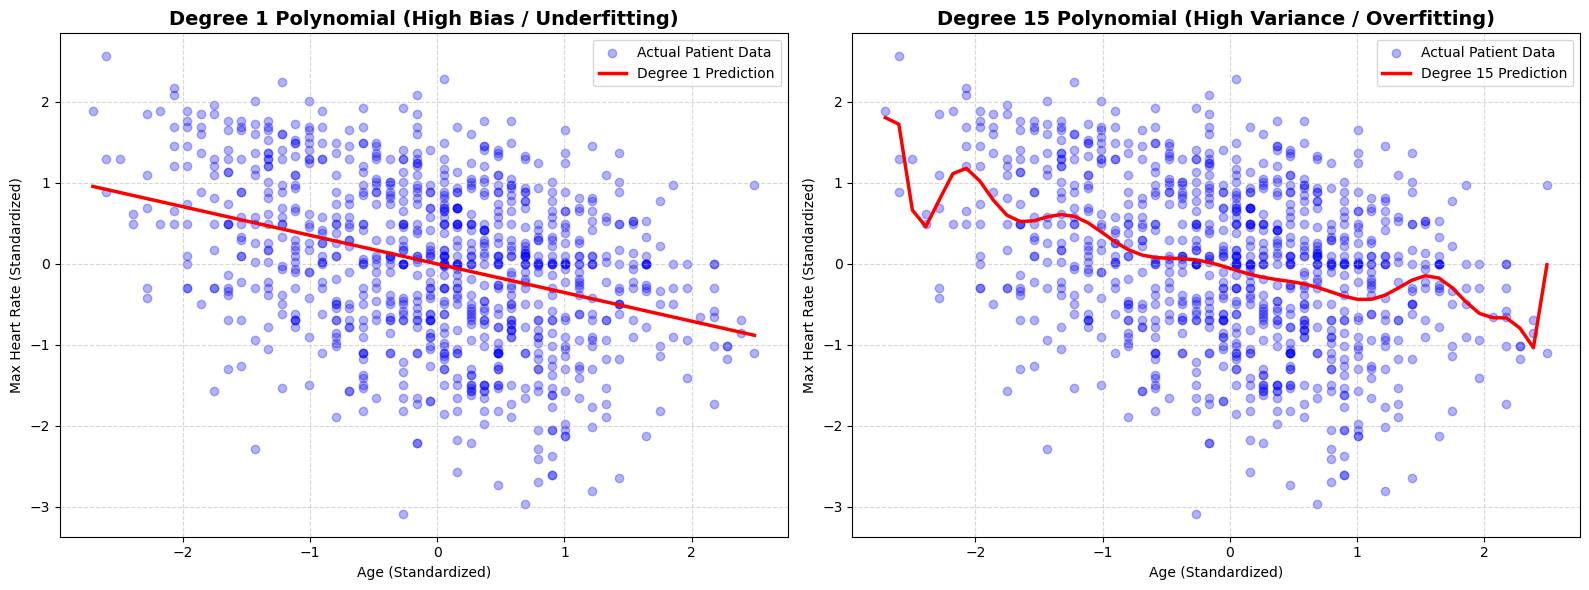

In [5]:
# Set up a wide, side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Degree 1 (A simple straight line)
# This represents High Bias (Underfitting) because it's too simple to capture any nuance in the data.
fit_and_plot(1, axes[0], "Degree 1 Polynomial (High Bias / Underfitting)")

# Plot 2: Degree 15 (A highly complex curve)
# This represents High Variance (Overfitting). Notice how it wildly swings up and down 
# just to chase individual outlier data points! It will fail completely on new, unseen data.
fit_and_plot(15, axes[1], "Degree 15 Polynomial (High Variance / Overfitting)")

plt.tight_layout()
plt.show()